# Задача 4. Реализация поиска кратчайших путей
## Трубачеев Борис Андреевич, группа S4101
#### Выполнены все подпункты задания.

##  1. Функция поиска кратчайших путей из заданной вершины (Bellman–Ford).

In [1]:
from graphblas import Vector, semiring, dtypes, binary
import pandas as pd


def bellman_ford(A, source: int):
    n = A.nrows
    
    v = Vector(dtypes.FP64, n)
    v[source] = 0.0

    for _ in range(n - 1):
        w = v.dup()
        
        v << v.ewise_add(v.vxm(A, semiring.min_plus), binary.min)
        
        if v.isequal(w):
            break

    w = v.ewise_add(v.vxm(A, semiring.min_plus), binary.min)
    if not w.isequal(v):
        return Vector(dtypes.FP64, n)

    return v

### 2. Функция поиска кратчайших путей из нескольких заданных вершин.

In [2]:
from graphblas import Matrix, semiring, dtypes, binary


def multi_source_bellman_ford(A, sources):
    n = A.nrows
    k = len(sources)

    D = Matrix(dtypes.FP64, k, n)

    for i, s in enumerate(sources):
        D[i, s] = 0.0

    for _ in range(n - 1):
        W = D.dup()
        
        D << D.ewise_add(D.mxm(A, semiring.min_plus), binary.min)
        
        if D.isequal(W):
            break

    W = D.ewise_add(D.mxm(A, semiring.min_plus), binary.min)
    if not W.isequal(D):
        return Matrix(dtypes.FP64, k, n)

    return D

### 3. Функции поиска кратчайших путей в ориентированном графе для всех пар вершин (Floyd–Warshall и вычисление транзитивного замыкания

Функция для алоритма Floyd–Warshall

In [3]:
from graphblas import Matrix, dtypes, binary

def floyd_warshall(A):
    n = A.nrows

    D = A.dup()

    for i in range(n):
        D[i, i] = 0.0

    for k in range(n):
        col_k = D[:, k]
        row_k = D[k, :]

        update = col_k.outer(row_k, binary.plus)
        D << D.ewise_add(update, binary.min)

    for i in range(n):
        val = D[i, i].new().value
        if val is not None and val < 0:
            return Matrix(dtypes.FP64, n, n)

    return D

Функция для алгортма транзитивного замыкания. Реализована через полукольцо min_plus для подсчета не только достижимости, но и минимального пути.

In [4]:
from graphblas import Matrix, dtypes, semiring, binary


def transitive_closure_min_plus(A):
    n = A.nrows
    D = A.dup()

    for i in range(n):
        D[i, i] = 0.0

    for _ in range(n):
        W = D.dup()

        D << D.ewise_add(D.mxm(D, semiring.min_plus), binary.min)

        if D.isequal(W):
            break

    for i in range(n):
        val = D[i, i].new().value
        if val is not None and val < 0:
            return Matrix(dtypes.FP64, n, n)

    return D

### 4. Добавить необходимые тесты.

Функция перевода нампай в coo представление графа в формате graphblas

In [5]:
import numpy as np

def numpy_to_graphblas(A: np.ndarray) -> Matrix:
    """
    Принимает: numpy-матрицу смежности.
    Возвращает: такую же матрицу GraphBLAS.
    """
    rows, cols = np.where(A != 0)
    vals = A[rows, cols]
    return Matrix.from_coo(rows, cols, vals, nrows=A.shape[0], ncols=A.shape[1])


Функция генерации тест-кейсов. Тест-кейсы рассматривают базовые варианты, разрывные графы, циклы и отрицательные циклы. ДЛя каждого кейса есть отдельно кейсы для одной стартовой вершины (классический Беллман-Форд), подмножества вершин (матричный Беллман-Форд) и для всех вершин(Floyd–Warshal и транзитивное замыкание)

In [6]:
import numpy as np
import graphblas as gb

def vector_to_list(v, n):
    result = []
    for i in range(n):
        val = v[i].new().value
        result.append(val if val is not None else float('inf'))
    return result

def matrix_to_list(M, n, k=None):
    if k is None:
        k = n
    result = []
    for i in range(k):
        row = []
        for j in range(n):
            val = M[i, j].new().value
            row.append(val if val is not None else float('inf'))
        result.append(row)
    return result


def numpy_to_graphblas(A: np.ndarray) -> gb.Matrix:
    """
    Принимает: numpy-матрицу смежности.
    Возвращает: такую же матрицу GraphBLAS.
    """
    rows, cols = np.where(A != 0)
    vals = A[rows, cols]
    return gb.Matrix.from_coo(rows, cols, vals, nrows=A.shape[0], ncols=A.shape[1])


def generate_test_cases(numpy_to_graphblas):
    test_cases = []

    # 1. Цепочка
    A = np.zeros((3, 3))
    A[0, 1] = 1
    A[1, 2] = 1

    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 1, 2])],
        [
            [0, 1, 2],
            [float('inf'), 0, 1],
            [float('inf'), float('inf'), 0]
        ],
        "Цепочка"
    ))
    
    
    # 2. Разветвление
    A = np.zeros((4, 4))
    A[0, 1] = 1
    A[0, 2] = 5
    A[1, 2] = 1
    A[2, 3] = 1
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 1, 2, 3])],
        [
            [0, 1, 2, 3],
            [float('inf'), 0, 1, 2],
            [float('inf'), float('inf'), 0, 1],
            [float('inf'), float('inf'), float('inf'), 0]
        ],
        "Разветвление"
    ))
    
    
    # 3. Несвязный граф
    A = np.zeros((4, 4))
    A[0, 1] = 1
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 1, float('inf'), float('inf')])],
        [
            [0, 1, float('inf'), float('inf')],
            [float('inf'), 0, float('inf'), float('inf')],
            [float('inf'), float('inf'), 0, float('inf')],
            [float('inf'), float('inf'), float('inf'), 0]
        ],
        "Несвязный граф"
    ))
    
    
    # 4. Граф с циклом (без отрицательных)
    A = np.zeros((3, 3))
    A[0, 1] = 2
    A[1, 2] = 3
    A[2, 0] = 1
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 2, 5])],
        [
            [0, 2, 5],
            [4, 0, 3],
            [1, 3, 0]
        ],
        "Положительный цикл"
    ))
    
    
    # 5. Отрицательные веса (без цикла)
    A = np.zeros((3, 3))
    A[0, 1] = 4
    A[0, 2] = 5
    A[1, 2] = -2
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 4, 2])],
        [
            [0, 4, 2],
            [float('inf'), 0, -2],
            [float('inf'), float('inf'), 0]
        ],
        "Отрицательные веса"
    ))
    
    
    # 6. Отрицательный цикл
    A = np.zeros((3, 3))
    A[0, 1] = 1
    A[1, 2] = -2
    A[2, 1] = -2
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [float('inf')] * 3)],
        [
            [float('inf')] * 3,
            [float('inf')] * 3,
            [float('inf')] * 3
        ],
        "Отрицательный цикл"
    ))
    
    
    # 7. Несколько источников
    A = np.zeros((4, 4))
    A[0, 1] = 1
    A[1, 2] = 1
    A[2, 3] = 1
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0, 1],
        [
            (0, [0, 1, 2, 3]),
            (1, [float('inf'), 0, 1, 2])
        ],
        [
            [0, 1, 2, 3],
            [float('inf'), 0, 1, 2],
            [float('inf'), float('inf'), 0, 1],
            [float('inf'), float('inf'), float('inf'), 0]
        ],
        "Несколько источников"
    ))
    
    
    # 8. Граф без рёбер
    A = np.zeros((3, 3))
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, float('inf'), float('inf')])],
        [
            [0, float('inf'), float('inf')],
            [float('inf'), 0, float('inf')],
            [float('inf'), float('inf'), 0]
        ],
        "Пустой граф"
    ))
    
    
    # 9. Полный граф
    A = np.ones((3, 3))
    np.fill_diagonal(A, 0)
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 1, 1])],
        [
            [0, 1, 1],
            [1, 0, 1],
            [1, 1, 0]
        ],
        "Полный граф"
    ))
    
    
    # 10. Длинный путь с альтернативами
    A = np.zeros((5, 5))
    A[0, 1] = 2
    A[1, 4] = 5
    A[0, 2] = 1
    A[2, 3] = 1
    A[3, 4] = 1
    
    test_cases.append((
        numpy_to_graphblas(A),
        [0],
        [(0, [0, 2, 1, 2, 3])],
        [
            [0, 2, 1, 2, 3],
            [float('inf'), 0, float('inf'), float('inf'), 5],
            [float('inf'), float('inf'), 0, 1, 2],
            [float('inf'), float('inf'), float('inf'), 0, 1],
            [float('inf'), float('inf'), float('inf'), float('inf'), 0]
        ],
        "Альтернативные пути"
    ))

    return test_cases

Функция сравнения листов (т.к. при матричных операциях иногда появляется погрешность)

In [7]:
import math

def compare_lists(a, b, eps=1e-9):
    for x, y in zip(a, b):
        if math.isinf(y):
            if not math.isinf(x):
                return False
        else:
            if abs(x - y) > eps:
                return False
    return True

Функция для теста всех алгоритмов одтельно проверяем все типы подачи стартовых вершин

In [8]:
def test_algorithm(func, func_name):
    print(f"\n==== Testing {func_name} ===")

    test_cases = generate_test_cases(numpy_to_graphblas)

    for A, sources, expected_multi, expected_all, name in test_cases:
        n = A.nrows

        if func_name == "Bellman-Ford":
            outputs = [vector_to_list(func(A, src), n) for src, _ in expected_multi]
            expected = [exp for _, exp in expected_multi]

        elif func_name == "Multi-source Bellman-Ford":
            D = func(A, sources)
            outputs = matrix_to_list(D, n, len(sources))
            expected = [exp for _, exp in expected_multi]

        elif func_name in ["Floyd-Warshall", "Transitive Closure (min-plus)"]:
            D = func(A)
            outputs = matrix_to_list(D, n)
            expected = expected_all

        if isinstance(expected[0], list):
            for r, e in zip(outputs, expected):
                if not compare_lists(r, e):
                    print(f"{func_name} упал тест: {name}, \n{r}, \n{e}")
                    return False
        else:
            for out, exp in zip(outputs, expected):
                if not compare_lists(out, exp):
                    print(f"{func_name} упал тест: {name}")
                    return False

    print(f"{func_name} работает корректно")
    return True

Запускаем тестыдля всех алгоритмов

In [9]:
test_algorithm(bellman_ford, "Bellman-Ford")
test_algorithm(multi_source_bellman_ford, "Multi-source Bellman-Ford")
test_algorithm(floyd_warshall, "Floyd-Warshall")
test_algorithm(transitive_closure_min_plus, "Transitive Closure (min-plus)")


==== Testing Bellman-Ford ===
Bellman-Ford работает корректно

==== Testing Multi-source Bellman-Ford ===
Multi-source Bellman-Ford работает корректно

==== Testing Floyd-Warshall ===
Floyd-Warshall работает корректно

==== Testing Transitive Closure (min-plus) ===
Transitive Closure (min-plus) работает корректно


True

Все тесты прошли успешно

### 5. Тесты на скаченных матрицах и случайно-сгенерированных (+3)

Функция загрузки графов и замера времени

In [10]:
from scipy.io import mmread


def load_graphblas_from_mtx(path: str) -> gb.Matrix:
    """
    Загружает .mtx файл по пути path в graphblas.Matrix
    """
    M = mmread(path).tocsr()
    
    rows, cols = M.nonzero()
    vals = M.data
    
    n = M.shape[0]
    
    A = gb.Matrix.from_coo(rows, cols, vals, nrows=n, ncols=n)
    A = A - gb.Matrix.diag(A.diag())
    
    return A

import time

def measure_time(func, A, sources):
    if sources is None:
        start = time.perf_counter()
        result = func(A)
        end = time.perf_counter()
    else:
        start = time.perf_counter()
        result = func(A, sources)
        end = time.perf_counter()
    
    return end - start, result

Функция тестовых прогонов скаченных графов

In [11]:
import os

def benchmark_downloaded_graphs(algorithms, algoritms_types, graphs_dir: str):
    """
    Прогоняет все алгоритмы по всем графам в папке
    и возвращает DataFrame с результататтами
    """
    
    records = []
    
    for filename in os.listdir(graphs_dir):
        if not filename.endswith(".mtx"):
            continue
        path = os.path.join(graphs_dir, filename)
        
        print(filename)
        
        A = load_graphblas_from_mtx(path)
        
        n = A.nrows
        nnz = A.nvals

        
        for i in range(len(algorithms)):
            func = algorithms[i]
            sources_cnt = np.ceil(np.logspace(1, np.log10(n - 1), 6)).astype(int)
            for source_cnt in sources_cnt:
                sources = [i for i in range(source_cnt) if i < n]
                if algoritms_types[i] == 'one_source':
                    time_spent = 0
                    for source in sources:
                        time_spent_new, _ = measure_time(func, A, source)
                        time_spent += time_spent_new
                elif algoritms_types[i] == 'multi_source':
                    time_spent, res = measure_time(func, A, sources)
                elif algoritms_types[i] == 'all_vert':
                    time_spent, res = measure_time(func, A, None)

                records.append({
                    "graph": filename,
                    "algorithm": func.__name__,
                    "n_vertices": n,
                    "nnz": nnz,
                    "p": nnz / n,
                    "sources_cnt": len(sources),
                    "time_sec": time_spent
                })
    
    df = pd.DataFrame(records)
    
    return df

Функция генерации случайных графов из прошлых заданий

In [12]:
def generate_random_graph(n: int, p: float, seed=None, batch_size=1_000_000):
    """
    Принимает кол-во вершин n и вероятность возникновения ребра p.
    Возвращает граф в формате gb.Matrix
    """
    try:
        rng = np.random.default_rng(seed)
        
        max_edges = n * (n - 1) // 2
        expected_edges = int(max_edges * p)
        
        rows = []
        cols = []
        
        generated = 0
        
        while generated < expected_edges:
            size = min(batch_size, expected_edges - generated)
            
            i = rng.integers(0, n, size=size, dtype=np.int64)
            j = rng.integers(0, n, size=size, dtype=np.int64)
            
            mask = i != j
            i = i[mask]
            j = j[mask]
            
            mask = i < j
            i = i[mask]
            j = j[mask]
            
            rows.append(i)
            cols.append(j)
            
            generated += len(i)
        
        rows = np.concatenate(rows)
        cols = np.concatenate(cols)
        
        rows_full = np.concatenate([rows, cols])
        cols_full = np.concatenate([cols, rows])
        
        A = gb.Matrix.from_coo(
            rows_full,
            cols_full,
            [1] * len(rows_full),
            nrows=n,
            ncols=n,
            dup_op=gb.binary.max
        )

        return A
    except Exception as e:
        print(f"Не удалось создать матрицу {n} вершин с вероятностью {p}, ошибка: {repr(e)}")
        
    

Функция прогона тестов для случайно сгенерированных графов

In [13]:
def benchmark_random_graphs(algorithms, algoritms_types, n_values, p_values):
    """
    Получает на вход список кол-ва вершин, список вероятностей возникновения ребер.

    Возвращает датафрейм со статистиками работы каждого алгоритма
    """
    
    records = []
    
    for n in n_values:                      
        for p in p_values:
            
            A = generate_random_graph(n, p, seed=42)
            if A is None:
                continue
            
            nnz = A.nvals
            
            for i in range(len(algorithms)):
                func = algorithms[i]
                sources_cnt = np.ceil(np.linspace(1, n, 10)).astype(int)
                for source_cnt in sources_cnt:
                    sources = [i for i in range(source_cnt) if i < n]
                    if algoritms_types[i] == 'one_source':
                        time_spent = 0
                        for source in sources:
                            time_spent_new, _ = measure_time(func, A, source)
                            time_spent += time_spent_new
                    elif algoritms_types[i] == 'multi_source':
                        time_spent, res = measure_time(func, A, sources)
                    elif algoritms_types[i] == 'all_vert':
                        time_spent, res = measure_time(func, A, None)
    
                    records.append({
                        "graph": f'random_{n}_{p}',
                        "algorithm": func.__name__,
                        "n_vertices": n,
                        "nnz": nnz,
                        "p": p,
                        "sources_cnt": len(sources),
                        "time_sec": time_spent
                    })
    
                print(f"n={n}, p={p}, {func.__name__}, time: {(time_spent):.3f}")
    
    return pd.DataFrame(records)

Функция запуска и по случайным графам, и по скаченным

In [14]:
def benchmark_all_graphs(algorithms, algoritms_types, graphs_dir):
    """
    Принимает список алгоритмов и путь к папке с графами 
    и запускает бенчмарки на скачанных и случайных графах.
    Возвращает: объединённый датафрейм с результатами всех экспериментов.
    """
    df_downloaded = benchmark_downloaded_graphs(algorithms, algoritms_types, graphs_dir)
    
    n_values =  np.logspace(np.log10(50), np.log10(1000), 10).astype(int)
    p_values = [0.0001, 0.001, 0.01, 0.1]
    df_rnd = benchmark_random_graphs(algorithms, algoritms_types, n_values, p_values)

    res = pd.concat([df_downloaded, df_rnd])

    return res


Проводим тестовые прогоны с замером времени

In [15]:
result = benchmark_all_graphs([bellman_ford, multi_source_bellman_ford, floyd_warshall, transitive_closure_min_plus], 
                              ['one_source', 'multi_source', 'all_vert', 'all_vert'],
                              "../../Graph Analysis/Lab3/graphs")

Erdos991.mtx
EX1.mtx
mycielskian10.mtx
mycielskian7.mtx
mycielskian8.mtx
mycielskian9.mtx
sphere3.mtx
Не удалось создать матрицу 49 вершин с вероятностью 0.0001, ошибка: ValueError('need at least one array to concatenate')
n=49, p=0.001, bellman_ford, time: 0.007
n=49, p=0.001, multi_source_bellman_ford, time: 0.001
n=49, p=0.001, floyd_warshall, time: 0.006
n=49, p=0.001, transitive_closure_min_plus, time: 0.002
n=49, p=0.01, bellman_ford, time: 0.008
n=49, p=0.01, multi_source_bellman_ford, time: 0.001
n=49, p=0.01, floyd_warshall, time: 0.007
n=49, p=0.01, transitive_closure_min_plus, time: 0.002
n=49, p=0.1, bellman_ford, time: 0.013
n=49, p=0.1, multi_source_bellman_ford, time: 0.002
n=49, p=0.1, floyd_warshall, time: 0.006
n=49, p=0.1, transitive_closure_min_plus, time: 0.002
Не удалось создать матрицу 69 вершин с вероятностью 0.0001, ошибка: ValueError('need at least one array to concatenate')
n=69, p=0.001, bellman_ford, time: 0.010
n=69, p=0.001, multi_source_bellman_ford, tim

Добавляем округленную долю стартовых вершин

In [16]:
result['sources_share'] = round(result['sources_cnt'] / result['n_vertices'], 1)
result

,graph,algorithm,n_vertices,nnz,p,sources_cnt,time_sec,sources_share
0,Erdos991.mtx,bellman_ford,492,2834,5.760163,10,0.008649,0.0
1,Erdos991.mtx,bellman_ford,492,2834,5.760163,22,0.017853,0.0
2,Erdos991.mtx,bellman_ford,492,2834,5.760163,48,0.038104,0.1
3,Erdos991.mtx,bellman_ford,492,2834,5.760163,104,0.087856,0.2
4,Erdos991.mtx,bellman_ford,492,2834,5.760163,226,0.177719,0.5
...,...,...,...,...,...,...,...,...
1435,random_1000_0.1,transitive_closure_min_plus,1000,95090,0.100000,556,0.330720,0.6
1436,random_1000_0.1,transitive_closure_min_plus,1000,95090,0.100000,667,0.330438,0.7
1437,random_1000_0.1,transitive_closure_min_plus,1000,95090,0.100000,778,0.330827,0.8
1438,random_1000_0.1,transitive_closure_min_plus,1000,95090,0.100000,889,0.331340,0.9


Функции визуализации

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns 

def plot_time_vs_size(df):
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df,
        x="n_vertices",
        y="time_sec",
        hue="algorithm",
        marker="o",
        errorbar=None
    )

    plt.title("Время работы vs размер графа")
    plt.xlabel("Число вершин")
    plt.ylabel("Время (сек)")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

def plot_time_vs_edges(df):
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df,
        x="nnz",
        y="time_sec",
        hue="algorithm",
        marker="o",
        errorbar=None
    )

    plt.title("Время работы vs число рёбер")
    plt.xlabel("nnz")
    plt.ylabel("Время (сек)")
    plt.xscale("log")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

def plot_time_vs_density(df):
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="p",
        y="time_sec",
        hue="algorithm"
    )

    sns.stripplot(
        data=df,
        x="p",
        y="time_sec",
        hue="algorithm",
        # dodge=True,
        # alpha=0.5,
        # color="black"
    )

    plt.title("Время работы vs разреженность графа")
    plt.xlabel("p = nnz / n")
    plt.ylabel("Время (сек)")
    plt.yscale("log")
    plt.legend(title="Алгоритм", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

def plot_time_vs_density_mean(df):
    grouped = (
        df.groupby(["p", "algorithm"])["time_sec"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=grouped,
        x="p",
        y="time_sec",
        hue="algorithm",
        marker="o"
    )

    plt.title("Среднее время vs разреженность")
    plt.xlabel("p")
    plt.ylabel("Среднее время (сек)")
    plt.xscale("log")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

def plot_time_vs_sources(df):
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df,
        x="sources_share",
        y="time_sec",
        hue="algorithm",
        marker="o",
        errorbar=None
    )

    plt.title("Время работы vs число источников")
    plt.xlabel("Количество источников")
    plt.ylabel("Время (сек)")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

def plot_algorithm_comparison(df):
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="algorithm",
        y="time_sec"
    )

    plt.title("Сравнение алгоритмов")
    plt.xlabel("Алгоритм")
    plt.ylabel("Время (сек)")
    plt.xticks(rotation=30)
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

def plot_facet_sources_share(df):
    g = sns.relplot(
        data=df[df['p'].isin([0.0001, 0.001, 0.01, 0.1])],
        x="n_vertices",
        y="time_sec",
        hue="algorithm",
        col="sources_share",
        kind="line",
        marker="o",
        errorbar=None,
        col_wrap=2
    )
    plt.yscale("log")

    g.fig.suptitle("Время vs размер графа при разном кол-ве стартовых вершин", y=1.02)

def plot_facet_p(df):
    g = sns.relplot(
        data=df,#[df['p'].isin([0.0001, 0.001, 0.01, 0.1])],
        x="n_vertices",
        y="time_sec",
        hue="algorithm",
        col="p",
        kind="line",
        marker="o",
        errorbar=None,
        col_wrap=2
    )
    plt.yscale("log")

    g.fig.suptitle("Время vs размер графа при разных p", y=1.02)

Визуализируем время работы алгоритмов

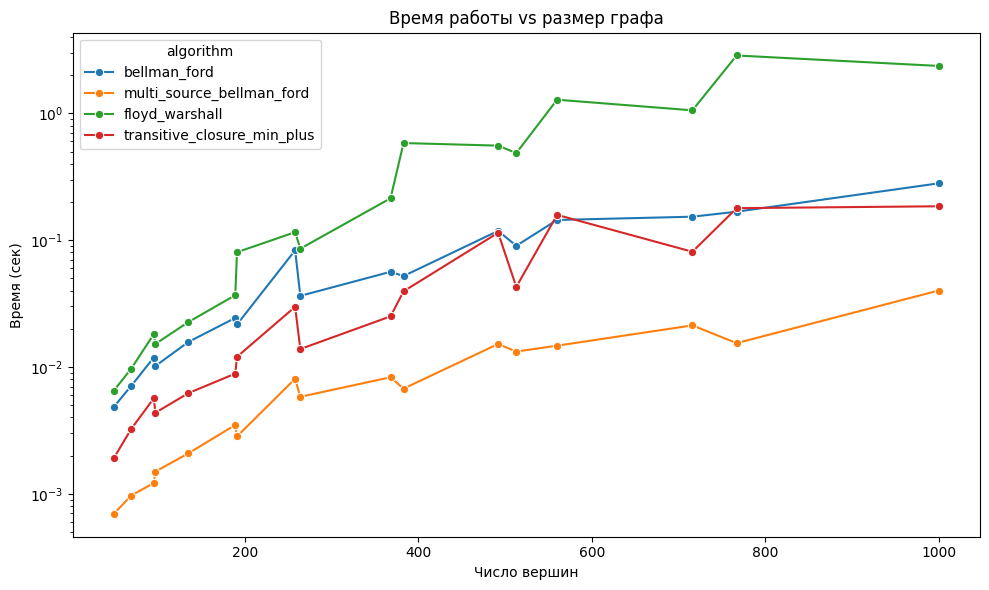

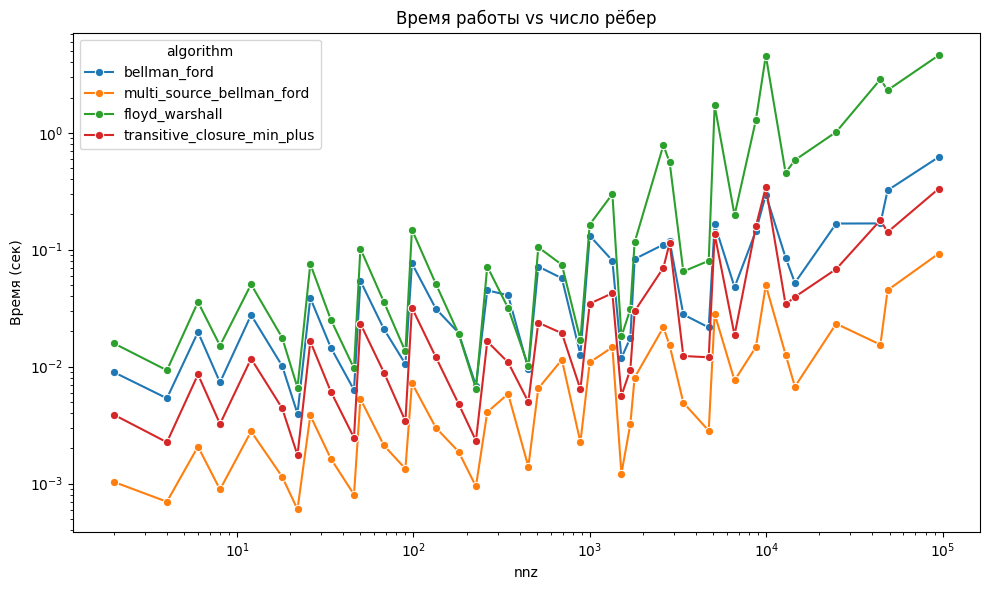

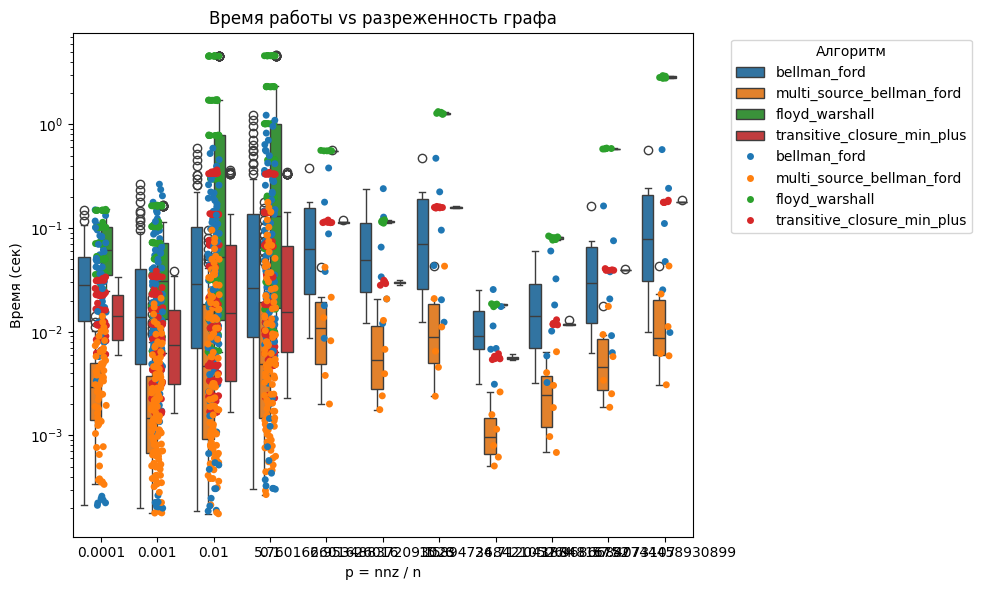

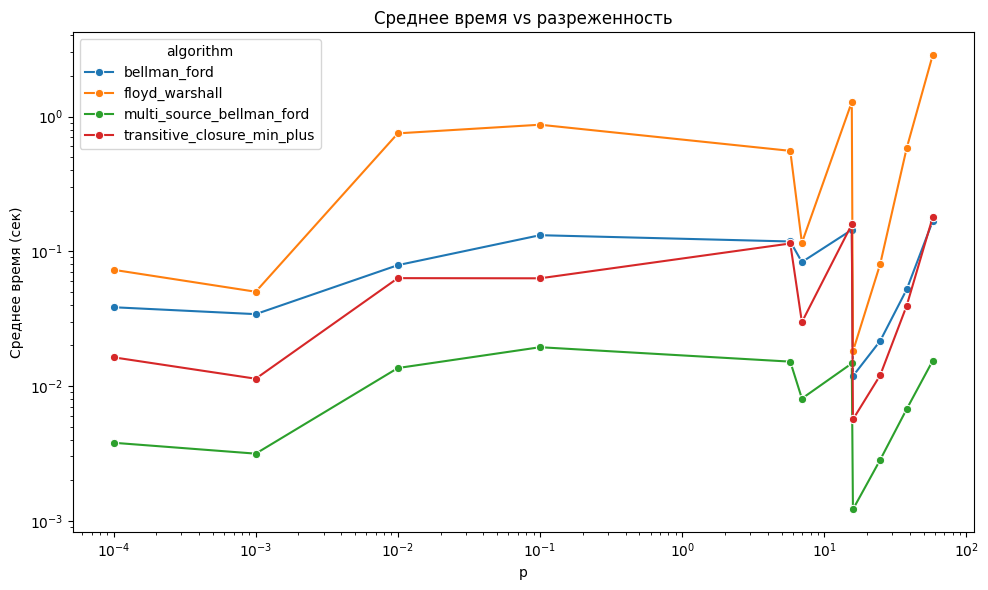

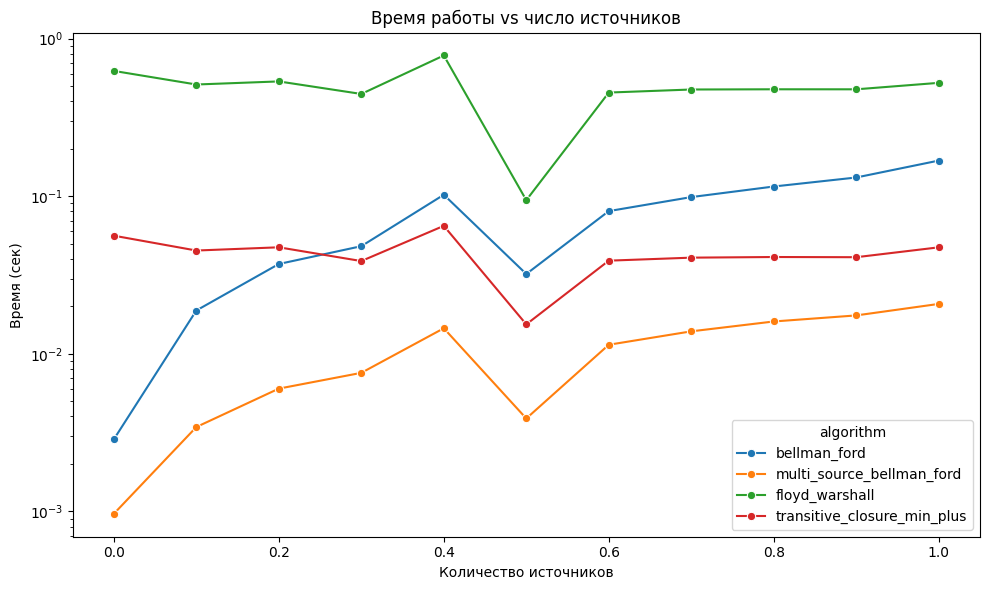

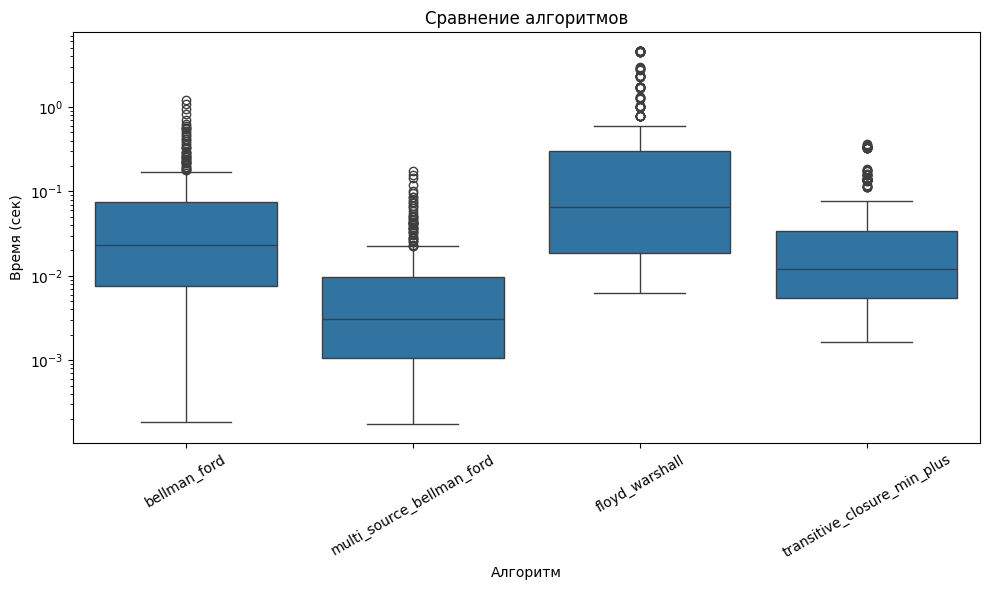

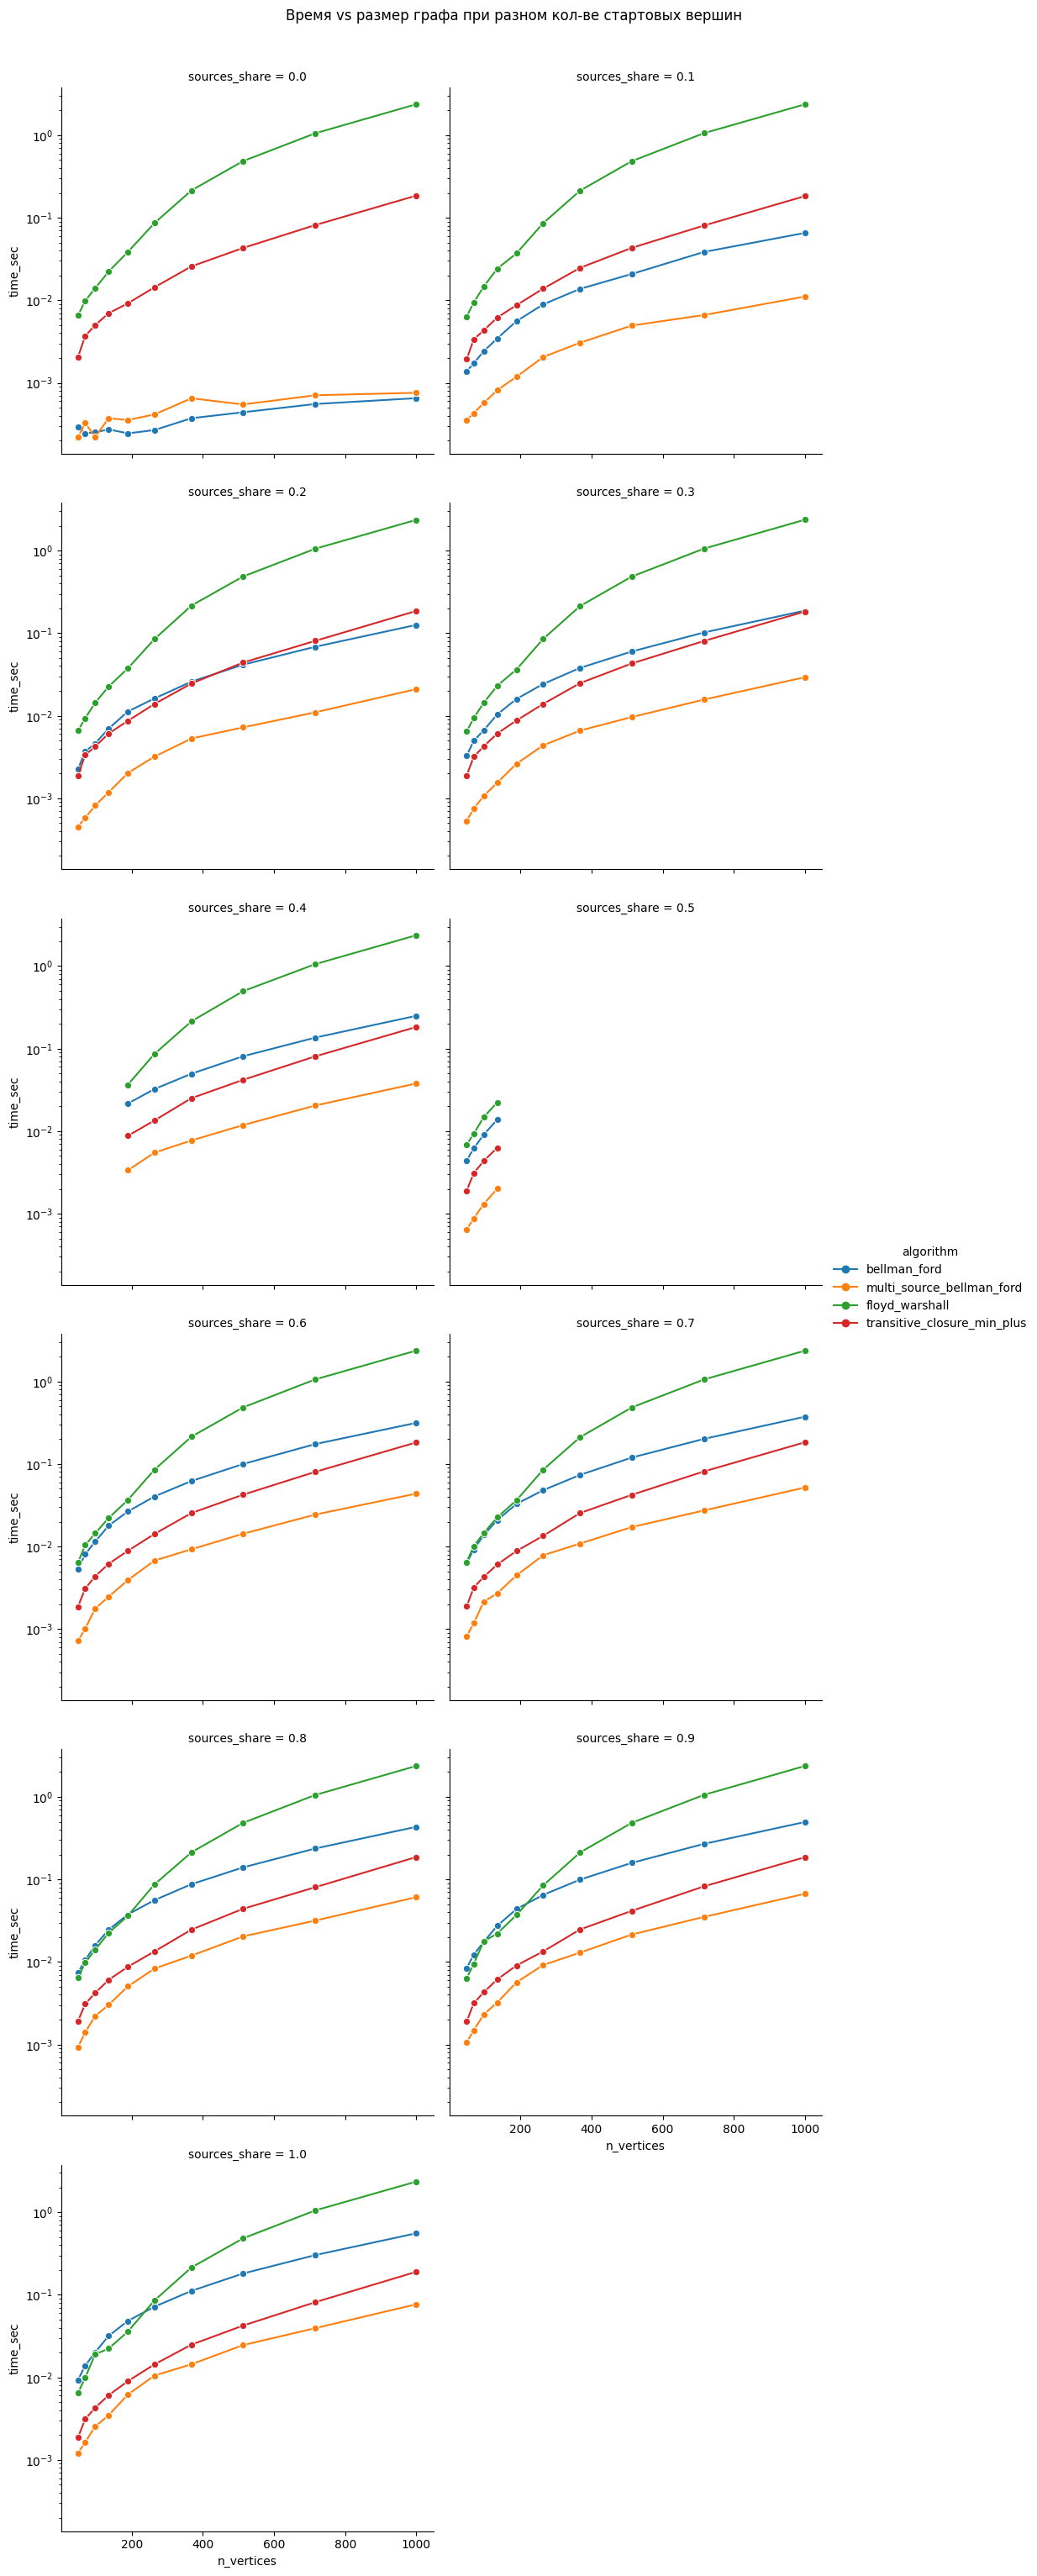

In [18]:
plot_time_vs_size(result)
plot_time_vs_edges(result)
plot_time_vs_density(result)
plot_time_vs_density_mean(result)
plot_time_vs_sources(result)
plot_algorithm_comparison(result)
plot_facet_sources_share(result)

Выводы:

1. Самый быстрый в среднем алгоритм: multi-source Bellman–Ford, далее идут транзитивное замыкание, стандартный Bellman–Ford и Floyd–Warshall.
2.  Время работы всех алгоримтов логарифмически растет с кол-вом вершин в графе. Сильнее всего зависимость у метода Floyd–Warshall.
3. Аналогично растет время работы от кол-ва ребер, т.е. ненулевых элементов матрицы. Время работы также растет вместе с ростом стемени разреженности графа, но менее явно.
4. Для алгоритмов поиска для всех вершин (Floyd–Warshall и транзитивного замыкания) время работы не зависит от кол-ва стартовых вершин, а для алгоритмов Bellman–Ford растет.
5. Начиная с 30% стартовых вершин алгоритм транзитивного замыкания работает быстрее стандартного Bellman–Ford. Возможно, при дальнейшем увеличении кол-ва вершин транзитивное замыкание побьет multi-source Bellman–Ford, однако проверить я это не могу в силу технических ограничений.

### Оценить эффект от использования push/pull direction optimization (+2)

Реализация  push/pull direction оптимизации и реализация гибридного метода , где в зависимости от наполненности вектора, при его определенном значении, переключается с push на pull.

In [19]:
def bf_push(A, source):
    n = A.nrows
    v = Vector(dtypes.FP64, n)
    v[source] = 0.0

    for _ in range(n - 1):
        w = v.dup()
        v << v.ewise_add(v.vxm(A, semiring.min_plus), binary.min)
        if v.isequal(w):
            break

    w = v.ewise_add(v.vxm(A, semiring.min_plus), binary.min)
    if not w.isequal(v):
        return Vector(dtypes.FP64, n)

    return v

def bf_pull(A, source):
    n = A.nrows
    v = Vector(dtypes.FP64, n)
    v[source] = 0.0

    for _ in range(n - 1):
        w = v.dup()

        new_v = A.T.mxv(v, semiring.min_plus)

        v << v.ewise_add(new_v, binary.min)

        if v.isequal(w):
            break

    new_v = A.T.mxv(v, semiring.min_plus)
    w = v.ewise_add(new_v, binary.min)

    if not w.isequal(v):
        return Vector(dtypes.FP64, n)

    return v

def bf_hybrid(A, source, threshold=0.1):
    n = A.nrows
    v = Vector(dtypes.FP64, n)
    v[source] = 0.0

    for _ in range(n - 1):
        w = v.dup()

        density = v.nvals / n

        if density < threshold:
            new_v = v.vxm(A, semiring.min_plus)
        else:
            new_v = A.T.mxv(v, semiring.min_plus)

        v << v.ewise_add(new_v, binary.min)

        if v.isequal(w):
            break

    if density < threshold:
        new_v = v.vxm(A, semiring.min_plus)
    else:
        new_v = A.T.mxv(v, semiring.min_plus)

    w = v.ewise_add(new_v, binary.min)

    if not w.isequal(v):
        return Vector(dtypes.FP64, n)

    return v

def bf_hybrid_01(A, source):
    return bf_hybrid(A, source, 0.1)

def bf_hybrid_02(A, source):
    return bf_hybrid(A, source, 0.2)

def bf_hybrid_005(A, source):
    return bf_hybrid(A, source, 0.05)

Протестируем реализации также, как и аллгоритм Bellman-Ford

In [20]:
test_algorithm(bf_push, "Bellman-Ford")
test_algorithm(bf_pull, "Bellman-Ford")
test_algorithm(bf_hybrid, "Bellman-Ford")


==== Testing Bellman-Ford ===
Bellman-Ford работает корректно

==== Testing Bellman-Ford ===
Bellman-Ford работает корректно

==== Testing Bellman-Ford ===
Bellman-Ford работает корректно


True

Алгоритмы работают корректно

Проведем тестовый прогон для ускоренных версий и обычного Bellman-Ford. Заупскаем в том числе с гибридным алгоритмом с порогами 0.05, 0.1, 0.2

In [21]:
def benchmark_random_graphs(algorithms, algoritms_types, n_values, p_values):
    """
    Получает на вход список кол-ва вершин, список вероятностей возникновения ребер.

    Возвращает датафрейм со статистиками работы каждого алгоритма
    """
    
    records = []
    
    for n in n_values:                      
        for p in p_values:
            
            A = generate_random_graph(n, p, seed=42)
            if A is None:
                continue
            
            nnz = A.nvals
            
            for i in range(len(algorithms)):
                func = algorithms[i]
                sources_cnt = np.ceil(np.linspace(1, n, 10)).astype(int)
                for source_cnt in sources_cnt:
                    sources = [i for i in range(source_cnt) if i < n]
                    if algoritms_types[i] == 'one_source':
                        time_spent, res = measure_time(func, A, sources[0])
                    elif algoritms_types[i] == 'multi_source':
                        time_spent, res = measure_time(func, A, sources)
                    elif algoritms_types[i] == 'all_vert':
                        time_spent, res = measure_time(func, A, None)
    
                    records.append({
                        "graph": f'random_{n}_{p}',
                        "algorithm": func.__name__,
                        "n_vertices": n,
                        "nnz": nnz,
                        "p": p,
                        "sources_cnt": len(sources),
                        "time_sec": time_spent
                    })
    
                print(f"n={n}, p={p}, {func.__name__}, time: {(time_spent):.3f}")
    
    return pd.DataFrame(records)

def benchmark_all_graphs(algorithms, algoritms_types, graphs_dir):
    """
    Принимает список алгоритмов и путь к папке с графами 
    и запускает бенчмарки на скачанных и случайных графах.
    Возвращает: объединённый датафрейм с результатами всех экспериментов.
    """
    
    n_values =  np.logspace(np.log10(50), np.log10(2000), 15).astype(int)
    p_values = np.logspace(np.log10(0.75), np.log10(0.99), 5)
    df_rnd = benchmark_random_graphs(algorithms, algoritms_types, n_values, p_values)

    return df_rnd

func_lst = [bellman_ford, bf_push, bf_pull, bf_hybrid_005, bf_hybrid_01, bf_hybrid_02]

res = benchmark_all_graphs(func_lst,
                              ['one_source'] * len(func_lst),
                              "../../Graph Analysis/Lab3/graphs")

n=49, p=0.75, bellman_ford, time: 0.000
n=49, p=0.75, bf_push, time: 0.000
n=49, p=0.75, bf_pull, time: 0.000
n=49, p=0.75, bf_hybrid_005, time: 0.000
n=49, p=0.75, bf_hybrid_01, time: 0.000
n=49, p=0.75, bf_hybrid_02, time: 0.000
n=49, p=0.8039050302961963, bellman_ford, time: 0.000
n=49, p=0.8039050302961963, bf_push, time: 0.000
n=49, p=0.8039050302961963, bf_pull, time: 0.000
n=49, p=0.8039050302961963, bf_hybrid_005, time: 0.000
n=49, p=0.8039050302961963, bf_hybrid_01, time: 0.000
n=49, p=0.8039050302961963, bf_hybrid_02, time: 0.000
n=49, p=0.8616843969807043, bellman_ford, time: 0.000
n=49, p=0.8616843969807043, bf_push, time: 0.000
n=49, p=0.8616843969807043, bf_pull, time: 0.000
n=49, p=0.8616843969807043, bf_hybrid_005, time: 0.000
n=49, p=0.8616843969807043, bf_hybrid_01, time: 0.000
n=49, p=0.8616843969807043, bf_hybrid_02, time: 0.000
n=49, p=0.9236165616807103, bellman_ford, time: 0.000
n=49, p=0.9236165616807103, bf_push, time: 0.000
n=49, p=0.9236165616807103, bf_pull,

Добавляем округленную долю стартовых вершин

In [22]:
res['sources_share'] = round(res['sources_cnt'] / res['n_vertices'], 1)
res

,graph,algorithm,n_vertices,nnz,p,sources_cnt,time_sec,sources_share
0,random_49_0.75,bellman_ford,49,1286,0.75,1,0.000446,0.0
1,random_49_0.75,bellman_ford,49,1286,0.75,7,0.000473,0.1
2,random_49_0.75,bellman_ford,49,1286,0.75,12,0.000370,0.2
3,random_49_0.75,bellman_ford,49,1286,0.75,17,0.000246,0.3
4,random_49_0.75,bellman_ford,49,1286,0.75,23,0.000519,0.5
...,...,...,...,...,...,...,...,...
4495,random_2000_0.99,bf_hybrid_02,2000,2514546,0.99,1112,0.015333,0.6
4496,random_2000_0.99,bf_hybrid_02,2000,2514546,0.99,1334,0.016018,0.7
4497,random_2000_0.99,bf_hybrid_02,2000,2514546,0.99,1556,0.016148,0.8
4498,random_2000_0.99,bf_hybrid_02,2000,2514546,0.99,1778,0.015283,0.9


Визуализируем

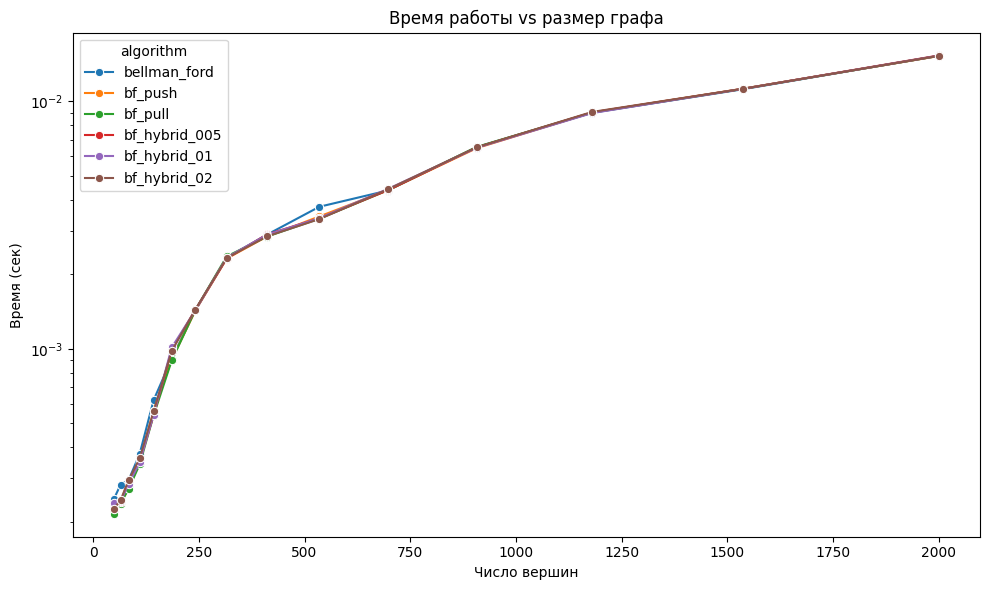

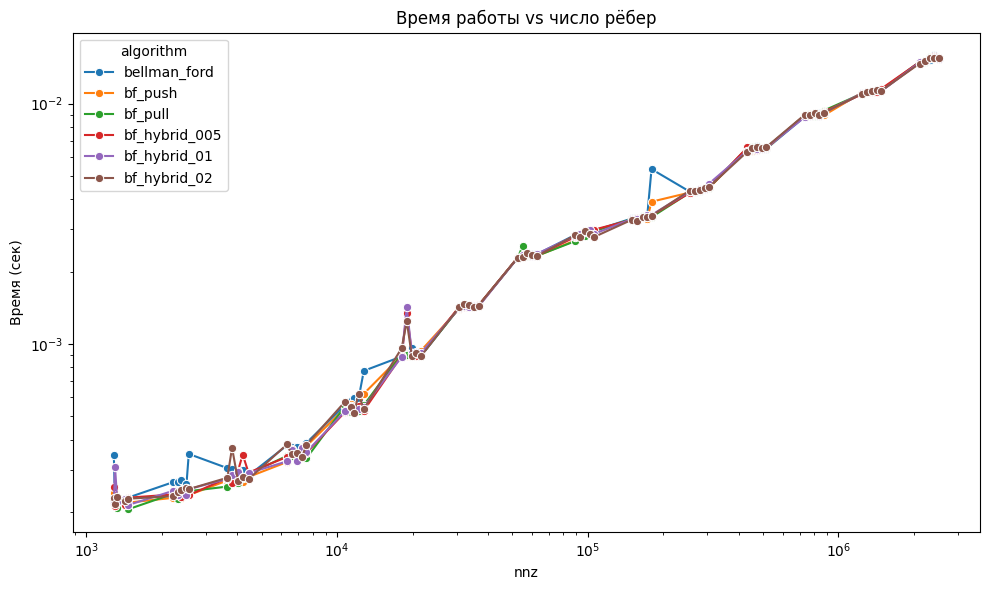

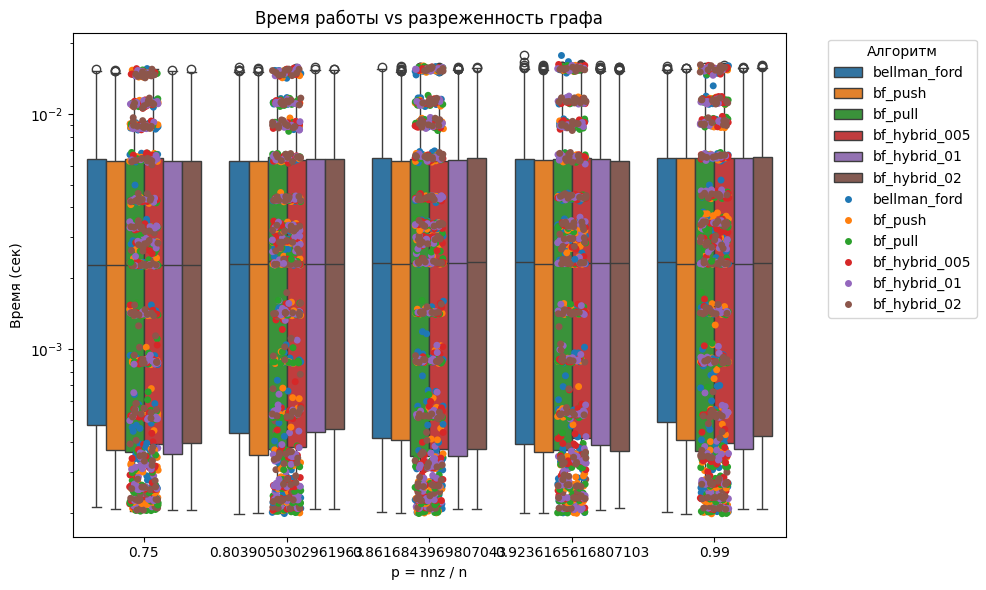

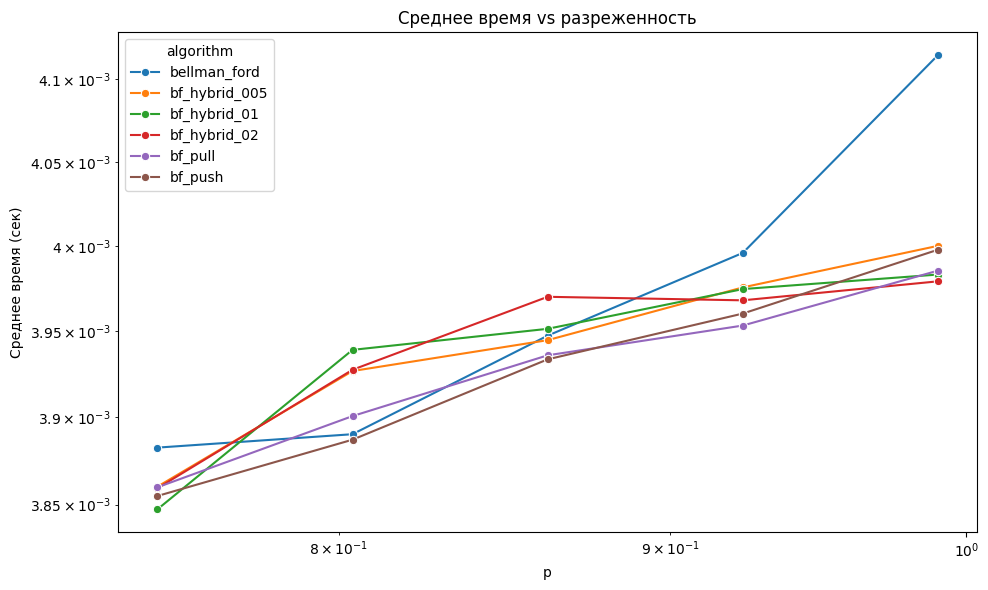

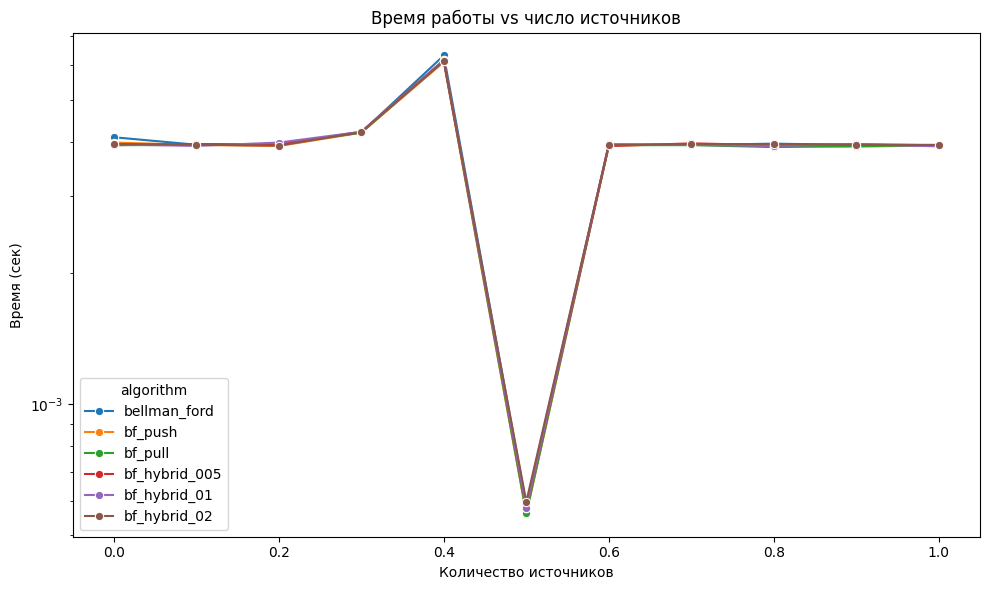

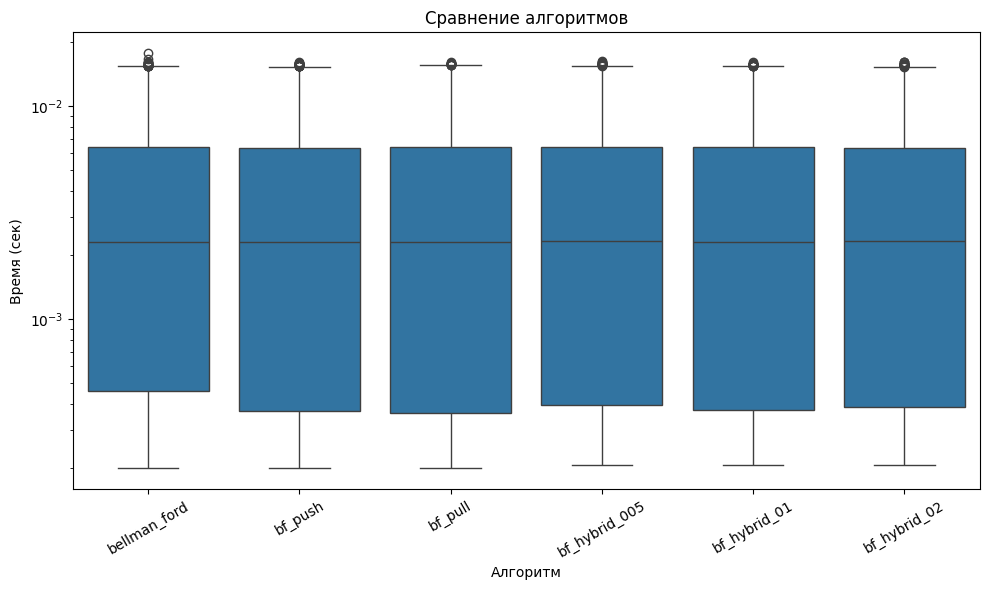

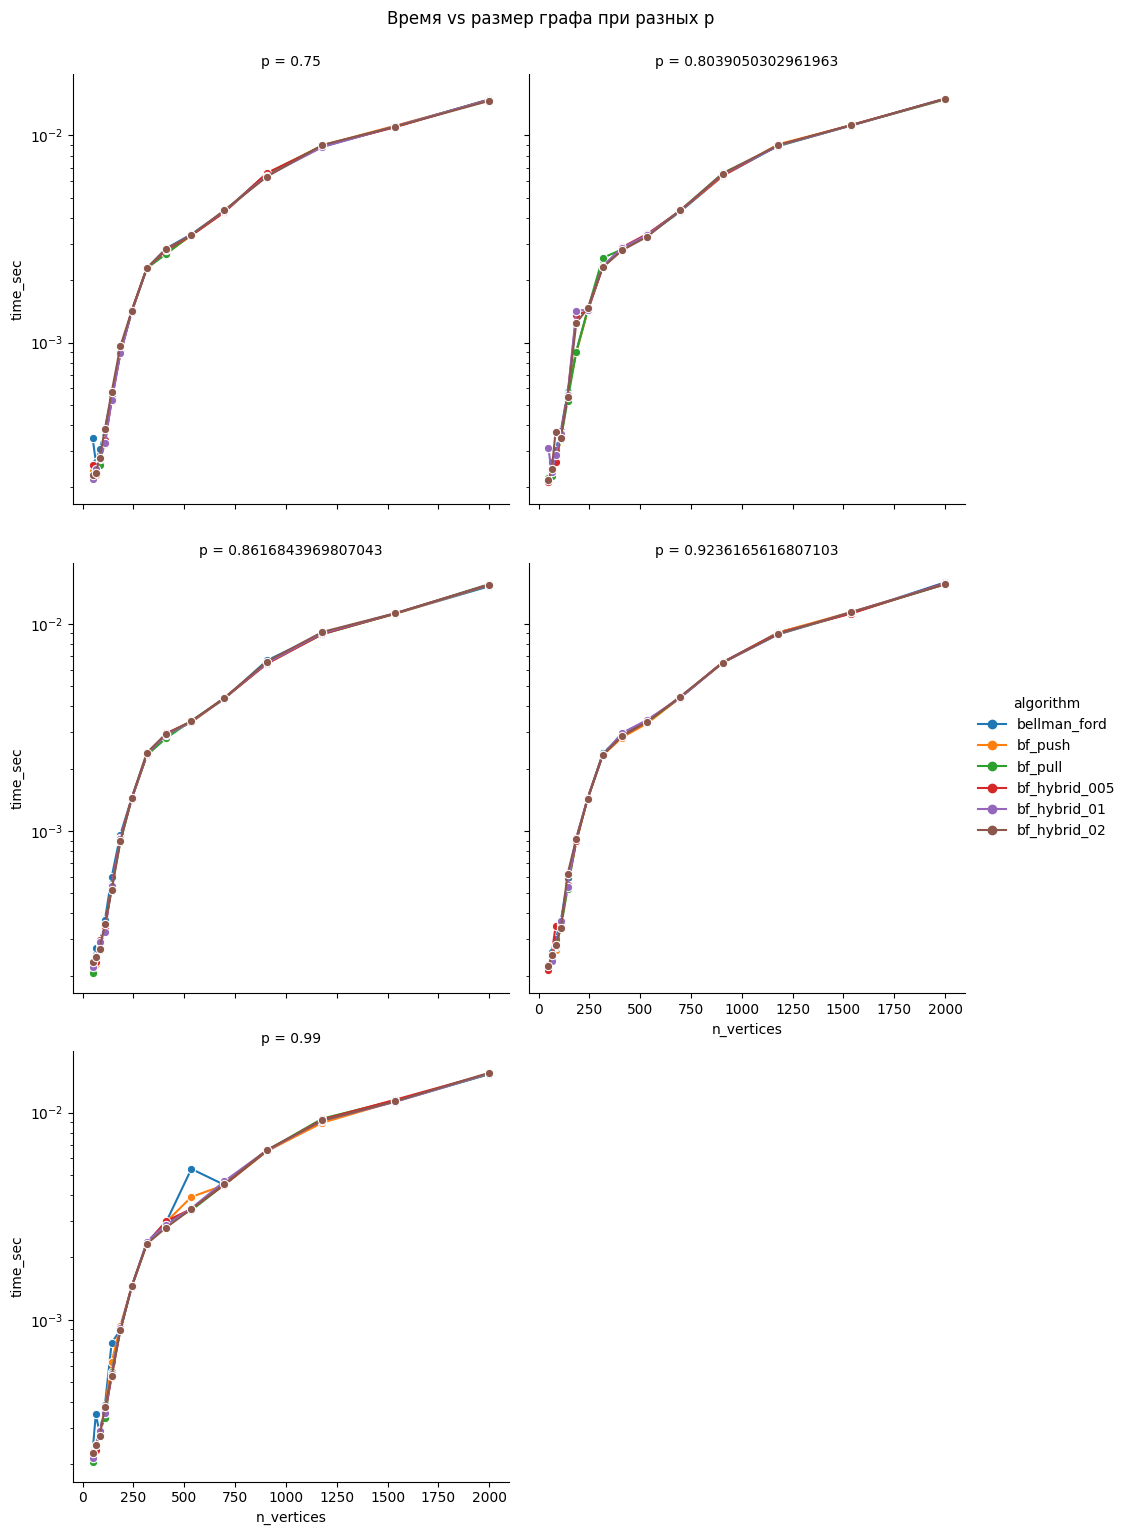

In [23]:
plot_time_vs_size(res)
plot_time_vs_edges(res)
plot_time_vs_density(res)
plot_time_vs_density_mean(res)
plot_time_vs_sources(res)
plot_algorithm_comparison(res)
plot_facet_p(res)

Выводы:

1. Видим, что на рассмотренном количестве вершин не выявлено сильных расхождений в скорости работы алгоритма в зависимости от оптимизации.
2. Немного хуже в среднем работает алоритм с pull оптимизацией
3. На графике зависимости от разреженности видим, что стандартная версия алгоритма работает чуть медленнее при росте степени разреженности графа, а алгоритм push снижает темпы роста при тех же условиях.
4. Больший эффект наверняка можно наблюдать на графах большего размера, но проверить это не могу в рамках технических ограничений.